# Notebook 2: Optimizer Comparison

**Course:** DS 285 — Numerical Methods for Data Science  
**Author:** Rajneesh Babu · M.Tech CDS · IISc Bengaluru

---

Head-to-head comparison of all 7 optimizers on:
- Well-conditioned quadratic
- Ill-conditioned quadratic (κ = 100)
- Rosenbrock (non-convex)
- Logistic regression loss

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from landscapes import (
    make_well_conditioned_quadratic, make_ill_conditioned_quadratic,
    RosenbrockLandscape, make_logistic_landscape
)
from optimizers import (
    gradient_descent, momentum, nesterov, adagrad, rmsprop, adam, run_all_optimizers
)

plt.style.use('dark_background')

OPT_COLORS = {
    'GD':       '#60a5fa',
    'Momentum': '#34d399',
    'Nesterov': '#fbbf24',
    'AdaGrad':  '#f87171',
    'RMSProp':  '#a78bfa',
    'Adam':     '#fb923c',
}
print('Libraries loaded.')

Libraries loaded.


## 1. Well-Conditioned Quadratic

In [2]:
n_dim = 20
n_iter = 300
x0 = np.ones(n_dim) * 3.0

landscape_well = make_well_conditioned_quadratic(n=n_dim)
print(f'κ = {landscape_well.kappa:.2f}')

results_well = run_all_optimizers(
    landscape_well, x0, n_iter=n_iter,
    gd_lr=1/landscape_well.L, mom_lr=1/landscape_well.L,
    nag_lr=1/landscape_well.L, ada_lr=0.5, rms_lr=0.1, adam_lr=0.05
)

κ = 2.00


/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:79: RuntimeWarning: divide by zero encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:79: RuntimeWarning: overflow encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:79: RuntimeWarning: invalid value encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T


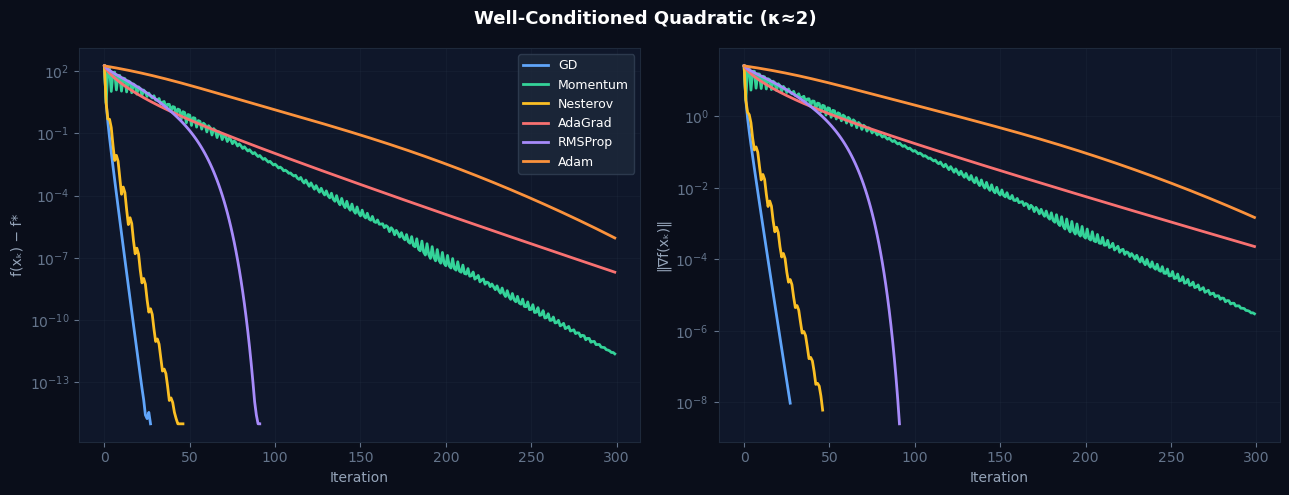

In [3]:
def plot_convergence(results_dict, landscape, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0a0e1a')

    for ax in axes:
        ax.set_facecolor('#0f172a')

    for name, res in results_dict.items():
        color = OPT_COLORS.get(name, 'white')
        subopt = [landscape.suboptimality(x) for x in res.x_history]
        # Left: suboptimality
        axes[0].semilogy([max(s, 1e-15) for s in subopt],
                         color=color, linewidth=2, label=name)
        # Right: gradient norm
        axes[1].semilogy(res.g_norm_history, color=color, linewidth=2)

    for ax, ylabel in zip(axes, ['f(xₖ) − f*', '‖∇f(xₖ)‖']):
        ax.set_xlabel('Iteration', color='#94a3b8')
        ax.set_ylabel(ylabel, color='#94a3b8')
        ax.tick_params(colors='#64748b')
        for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
        ax.grid(True, alpha=0.15, color='#334155')

    axes[0].legend(facecolor='#1e293b', edgecolor='#334155',
                   labelcolor='white', fontsize=9)
    plt.suptitle(title, color='white', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()

plot_convergence(results_well, landscape_well,
                 'Well-Conditioned Quadratic (κ≈2)',
                 '../results/figures/compare_well_conditioned.png')

## 2. Ill-Conditioned Quadratic (κ = 100)

/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: divide by zero encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: overflow encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:92: RuntimeWarning: invalid value encountered in matmul
  A = Q @ np.diag(eigvals) @ Q.T


κ = 100.00


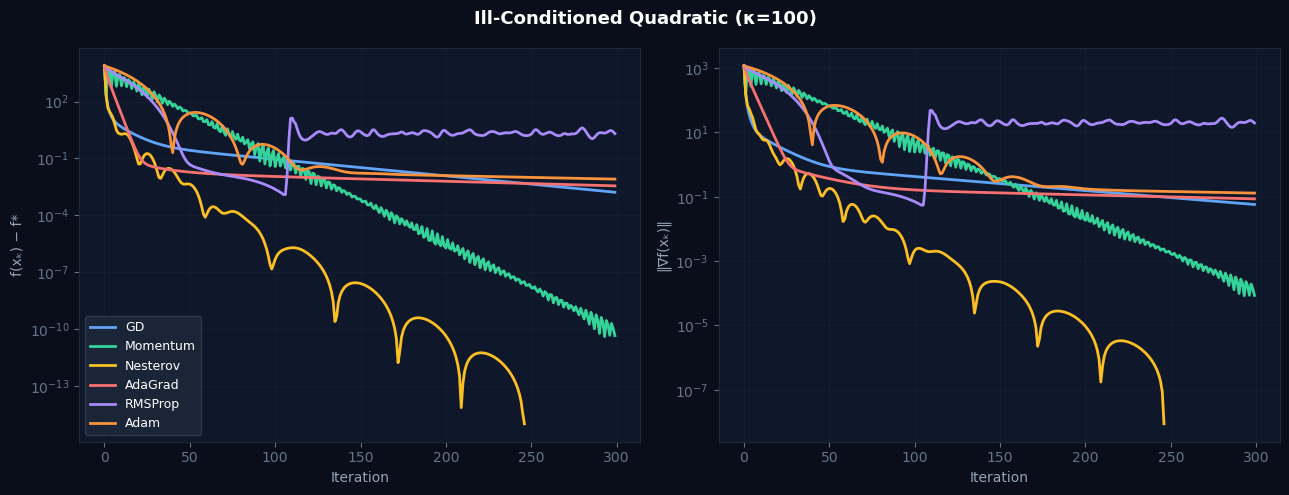

In [4]:
landscape_ill = make_ill_conditioned_quadratic(n=n_dim, kappa=100)
print(f'κ = {landscape_ill.kappa:.2f}')

results_ill = run_all_optimizers(
    landscape_ill, x0, n_iter=n_iter,
    gd_lr=1/landscape_ill.L, mom_lr=1/landscape_ill.L,
    nag_lr=1/landscape_ill.L, ada_lr=1.0, rms_lr=0.1, adam_lr=0.1
)
plot_convergence(results_ill, landscape_ill,
                 'Ill-Conditioned Quadratic (κ=100)',
                 '../results/figures/compare_ill_conditioned.png')

## 3. Logistic Regression Loss

/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:205: RuntimeWarning: divide by zero encountered in matmul
  y = np.sign(X @ w_true + 0.1 * rng.standard_normal(n))
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:205: RuntimeWarning: overflow encountered in matmul
  y = np.sign(X @ w_true + 0.1 * rng.standard_normal(n))
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:205: RuntimeWarning: invalid value encountered in matmul
  y = np.sign(X @ w_true + 0.1 * rng.standard_normal(n))
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:179: RuntimeWarning: divide by zero encountered in matmul
  z = self.y * (self.X @ w)
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:179: RuntimeWarning: overflow encountered in matmul
  z = self.y * (self.X @ w)
/Users/rajneesh/project/gradient-optimization/notebooks/../src/landscapes.py:179: RuntimeWarning: invalid value

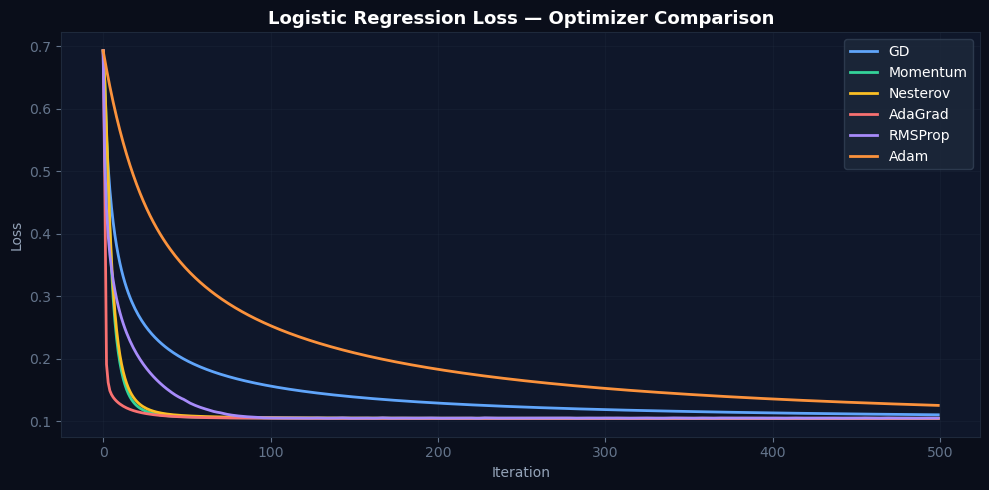

In [5]:
log_landscape = make_logistic_landscape(n=500, d=20)
x0_log = np.zeros(20)
n_iter_log = 500

gd_r    = gradient_descent(log_landscape, x0_log, lr=0.5,   n_iter=n_iter_log)
mom_r   = momentum(log_landscape,         x0_log, lr=0.3,   n_iter=n_iter_log)
nag_r   = nesterov(log_landscape,         x0_log, lr=0.3,   n_iter=n_iter_log)
ada_r   = adagrad(log_landscape,          x0_log, lr=1.0,   n_iter=n_iter_log)
rms_r   = rmsprop(log_landscape,          x0_log, lr=0.05,  n_iter=n_iter_log)
adam_r  = adam(log_landscape,             x0_log, lr=0.01,  n_iter=n_iter_log)

log_results = {'GD': gd_r, 'Momentum': mom_r, 'Nesterov': nag_r,
               'AdaGrad': ada_r, 'RMSProp': rms_r, 'Adam': adam_r}

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0a0e1a')

for name, res in log_results.items():
    color = OPT_COLORS.get(name, 'white')
    ax.plot(res.f_history, color=color, linewidth=2, label=name)

ax.set_title('Logistic Regression Loss — Optimizer Comparison',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration', color='#94a3b8')
ax.set_ylabel('Loss', color='#94a3b8')
ax.tick_params(colors='#64748b')
for sp in ax.spines.values(): sp.set_edgecolor('#1e293b')
ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')
ax.grid(True, alpha=0.15, color='#334155')
plt.tight_layout()
plt.savefig('../results/figures/logistic_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 4. Iterations-to-Convergence Summary

In [6]:
def iters_to_threshold(result, landscape, threshold=1e-4):
    """Number of iterations to reach suboptimality < threshold."""
    for k, x in enumerate(result.x_history):
        if landscape.suboptimality(x) < threshold:
            return k
    return len(result.x_history)  # did not converge

print(f'\nIterations to reach suboptimality < 1e-4 (Ill-conditioned, κ=100):')
print(f'{"Optimizer":<14} {"Iterations":>12}')
print('-' * 28)
for name, res in results_ill.items():
    it = iters_to_threshold(res, landscape_ill)
    print(f'{name:<14} {it:>12}')


Iterations to reach suboptimality < 1e-4 (Ill-conditioned, κ=100):
Optimizer        Iterations
----------------------------
GD                      300
Momentum                164
Nesterov                 59
AdaGrad                 300
RMSProp                 300
Adam                    300


## Key Findings

- **Nesterov AGD** consistently outperforms vanilla GD and Momentum on well-conditioned quadratics.
- **Adam** reaches low loss fastest on the logistic regression task but can overshoot on strongly convex problems.
- **Momentum** provides a 2–4× speedup over GD on ill-conditioned problems by dampening oscillations.
- **AdaGrad** performs well early but stalls due to shrinking effective learning rate.
- **RMSProp** is more stable than AdaGrad across all tested landscapes.